In [3]:
from scipy.integrate import solve_ivp
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

from copy import deepcopy # Deepcopy is needed to create genotypes which inherit previous genotypes' properties. Deepcopy needed because of lists being used (mutable)
from random import random

from random import choice
#import numpy.typing as npt
#from numba import njit, jit

import seaborn as sns
from GDA_ODEvolution_final import *


from matplotlib.colors import ListedColormap
# This option is needed in order to be able to edit text in Inkscape/Illustrator
plt.rcParams['svg.fonttype'] = 'none'


SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Method to convert inch to centimetres for figures:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

golden = 1.618
sizecm=8.9
sizecm = 12
figsize = cm2inch(sizecm,sizecm/golden)
widesize = tuple([figsize[0]*2,figsize[1]])
plt.rcParams['figure.figsize'] = figsize


## Figure 3A evolution experiment:

1. Set baseline: Grow colony, starting from a single cell. GDAs are generated.
2. Pick colony and grow in 6 ml
3. Inoculate 10 ml wit 32 CAZ with 0.1 ml
4. Evolve at 32 CAZ in 10 ml, 0.1 ml sampling

The amount of resource (gluc_start) is used to control cell final cell densities in accordance with experimental values.
Single experiment run at 32 µg/ml CAZ:

In [ ]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)

base.gluc_start = 2.5 # Resource amount has to be set for the run after next. 2.5 is the concentration that results in cell number corresponding to OD 0.5 in 6 ml tube, which is the condition of the experiment.
base.conduct(1) #  Grow up colony

base.volume = 10
base.sample_volume = 0.1
base.gluc_start = 40
base.conduct(1) # Grow in 6 ml tube to OD 0.5
base.set_antibiotic(32)
base.gluc_start = 40
base.conduct(20) # Run evolution experiment for 20 transfers


Cell number over the course of the experiment:

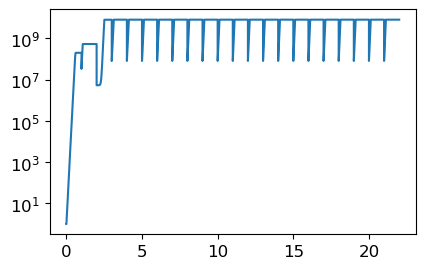

In [ ]:
plt.plot(base.from_genos('ts').T[0]/24, base.from_genos('n').sum(axis =1)[:-1])
plt.yscale('log')
plt.xlabel('Time (days)')
plt.ylabel('Total population size')

Plot results starting from first time in 32 CAZ:

C:\Users\nnordhol\AppData\Local\Temp\ipykernel_43952\1390954136.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon = False)


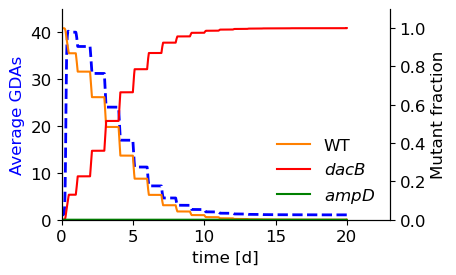

In [198]:
fig, ax1 = plt.subplots()

days_to_skip = 2

ax2 = ax1.twinx()
ax1.plot(base.genotypes[0].ts[np.where((base.genotypes[0].ts)>(days_to_skip*24))]/24 - (days_to_skip*24)/24, np.array(base.average_gdas[1:])[np.where((base.genotypes[0].ts)>(days_to_skip*24))],'--', c='#0000ff', lw = 2)
ax1.set_ylim([0, 45])
ax1.set_xlim([0,23])
ax1.legend(frameon = False)
#ax1.set_yscale('log')


ax2.set_prop_cycle(color = ['#ff8000', '#ff0000','#008000'])
ax2.plot(base.genotypes[0].ts[np.where((base.genotypes[0].ts)>(days_to_skip*24))]/24 - (days_to_skip*24)/24, np.array(base.background_fractions[1:])[np.where((base.genotypes[0].ts)>(days_to_skip*24))], label = ['WT', '$dacB$', '$ampD$'], lw = 1.5)




#ax2.set_ylim([10**-8, 2])


ax1.set_xlabel('time [d]')
ax1.set_ylabel('Average GDAs', color = '#0000ff')
ax2.set_ylabel('Mutant fraction')
ax2.set_ylim([0,1.1])

ax2.legend(frameon = False)

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

plt.tight_layout()

fig.savefig('Paper_figures/Single_run_CAZ_32.svg')

fig.savefig('Paper_figures/Single_run_CAZ_32.png', dpi = 300)

## Figure 3 B: Mutant takeover with and without GDAs

Set baseline for WT with GDAs:

In [200]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)


base.gluc_start = 40 # This has to be set befor the conduct for the next cycle
base.conduct(1) # Grow up colony
base.volume = 10
base.sample_volume = 0.1


Copy base experiment and run in increasing CAZ concentrations in steps of 1 µg/ml. This takes long. Reduce the number of concentrations to speed up (antibs).

In [201]:
antibs = range(128)
final_cycles = []
final_fractions = []
for a in antibs:
    exp = deepcopy(base)
    exp.set_antibiotic(a)
    bgs = exp.background_fractions[-1]
    cnt = 0
    while bgs[0]>0.05 and cnt < 20:
        exp.conduct(1) # Inoculate into medium
        bgs = exp.background_fractions[-1]
        cnt +=1
    #print(cnt, bgs)
    final_cycles.append(cnt)
    final_fractions.append(bgs)


KeyboardInterrupt: 

Set baseline for GDA- strain (k_dup = 0; k_rec = 0):

In [ ]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 0, k_rec = 0, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 750), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3000)})], gluc_start=1, volume = 6, sample_volume=1)


base.gluc_start = 40 # For some reason, this has to be set befor the conduct....
base.conduct(1) # Grow up colony
base.volume = 10
base.sample_volume = 0.1

Copy base experiment and run in increasing CAZ concentrations in steps of 1 µg/ml:

In [ ]:
final_cycles_no_gda = []
final_fractions_no_gda = []
for a in antibs:
    exp = deepcopy(base)
    exp.set_antibiotic(a)
    bgs = exp.background_fractions[-1]
    cnt = 0
    while bgs[0]>0.05 and cnt < 20:
        exp.conduct(1) # Inoculate into medium
        bgs = exp.background_fractions[-1]
        cnt +=1
    #print(a, cnt, bgs)
    final_cycles_no_gda.append(cnt)
    final_fractions_no_gda.append(bgs)


0 20 [np.float64(0.999998905272709), np.float64(1.0624664904825098e-06), np.float64(3.2260800533536884e-08)]
1 20 [np.float64(0.9999988969453153), np.float64(1.0707683654126074e-06), np.float64(3.2286319267451316e-08)]
2 20 [np.float64(0.9999834838370064), np.float64(1.6475679187846867e-05), np.float64(4.048380582470899e-08)]
3 4 [np.float64(0.024904164378668492), np.float64(0.9746735608918048), np.float64(0.0004222747295266384)]
4 1 [np.float64(0.004158256251301663), np.float64(0.9920961853445764), np.float64(0.0037455584041219897)]
5 1 [np.float64(0.0041493764305477986), np.float64(0.9921051035163809), np.float64(0.0037455200530712726)]
6 1 [np.float64(0.0041493764305477986), np.float64(0.9921051035163809), np.float64(0.0037455200530712726)]
7 1 [np.float64(0.0041493764305477986), np.float64(0.9921051035163809), np.float64(0.0037455200530712726)]
8 1 [np.float64(0.004149376430547802), np.float64(0.9921051035163809), np.float64(0.003745520053071291)]
9 1 [np.float64(0.0041493764305478

Plot:

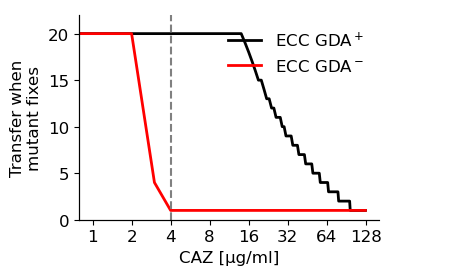

In [ ]:
f,ax1 = plt.subplots()

plt.plot(antibs, final_cycles, label = r'ECC GDA$^+$', lw = 2, color = 'k')
plt.plot(antibs, final_cycles_no_gda, label = r'ECC GDA$^-$', lw = 2, color = 'r')

# plt.axvline(exp.from_genos('ic50')[0],ls = '--', c = 'k', label = 'IC50')
# plt.axvline(exp.from_genos('mic')[0],ls = '--', c = 'gray', label = 'MIC')
plt.xscale('log', base = 2)
plt.ylabel('Transfer when\nmutant fixes')
plt.xlabel('CAZ [µg/ml]')
plt.ylim([0,22])
plt.legend(loc = 'upper right', frameon = False)
plt.axvline(exp.from_genos('mic')[0],ls = '--', c = 'gray', label = 'MIC')

plt.xticks([1,2,4,8,16,32,64,128],[1,2,4,8,16,32,64,128])

ax2 = ax1.twinx()
ax2.set_ylabel(' ', color = 'w')
ax2.set_ylim([0,0.15])
ax2.set_yticks([0,0.05,0.2])

f.tight_layout()

ax1.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
ax2.tick_params(axis='y', colors='w')

f.savefig('./Paper_figures/Mutant_takeover_cost_10-3.png', dpi = 300)
f.savefig('./Paper_figures/Mutant_takeover_cost_10-3.svg')

## Figure 3 C

In [ ]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)


base.gluc_start = 2.5 # For some reason, this has to be set befor the conduct....
base.conduct(1) # Run with 1 glucose
base.gluc_start = 1
base.sample_volume = 0.12
base.conduct(1)


ab_conc =  np.logspace(0,8,80, base=2)


l5 = []
j5 = []

for a in ab_conc:
    #print(f'Calculatin CAZ {a}...')
    exp = deepcopy(base)
    exp.set_antibiotic(a)
    exp.conduct(5)
    l5.append(exp.average_gdas[-1])
    j5.append(exp.background_fractions[-1])
    #print('done.')


Calculatin CAZ 1.0...
done.
Calculatin CAZ 1.3389041012244722...
done.
Calculatin CAZ 1.7926641922757116...
done.
Calculatin CAZ 2.4002054391562058...
done.
Calculatin CAZ 3.2136449062675294...
done.
Calculatin CAZ 4.30276234488073...
done.
Calculatin CAZ 5.760986150155036...
done.
Calculatin CAZ 7.71340798353996...
done.
Calculatin CAZ 10.327513583579238...
done.
Calculatin CAZ 13.827550292505688...
done.
Calculatin CAZ 18.513763796523513...
done.
Calculatin CAZ 24.788154276266496...
done.
Calculatin CAZ 33.18896142227814...
done.
Calculatin CAZ 44.436836563668976...
done.
Calculatin CAZ 59.49666272053799...
done.
Calculatin CAZ 79.6603257256975...
done.
Calculatin CAZ 106.65753681901367...
done.
Calculatin CAZ 142.80421347347752...
done.
Calculatin CAZ 191.20114709177412...
done.
Calculatin CAZ 256.0...
done.


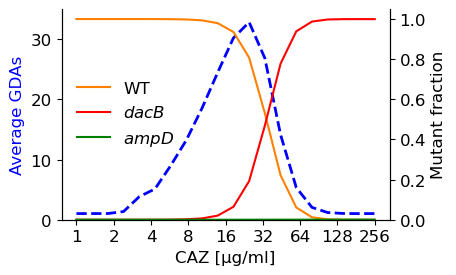

In [204]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax2.set_prop_cycle(color = ['#ff8000', '#ff0000','#008000'])

ax1.set_ylim([0, 35])

plt.xscale('log', base = 2)

ax1.plot(ab_conc[:], l5[:], '--', lw = 2, c = 'b')

ax2.plot(ab_conc[:], j5[:], label = ['WT', '$dacB$', '$ampD$'])
plt.xscale('log', base = 2)

plt.xscale('log', base = 2)
plt.xticks([1,2,4,8,16,32,64,128,256],[1,2,4,8,16,32,64,128,256])


ax1.set_xlabel('CAZ [µg/ml]')
ax1.set_ylabel('Average GDAs', color = 'b')
ax2.set_ylabel('Mutant fraction')
ax2.set_ylim([0, 1.05])

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

ax2.legend(frameon = False, loc = 'center left')

plt.tight_layout()

figname = 'Average_GDAs_mutant_frac_CAZ_5_cycles'

fig.savefig(f'./Paper_figures/{figname}.svg', bbox_inches = 'tight')
fig.savefig(f'./Paper_figures/{figname}.png', bbox_inches = 'tight')

## Figure 3 D: Plot for 'rescue' experiment

For this experiment, the idea is to see if a population that was pre-grown without CAZ is able to establish a population in 32 CAZ (or similar) at different dilutions.

1. Grow colony from single cell.
2. Grow colony in 6 ml medium
3. Prepare different dilutions and grow in 6 ml medium with CAZ
4. Growth or no growth?

## Add heterogeneity measure:

Demonstrate that GDAs introduce population heterogeneity in MIC. Characterize heterogeneity in context of rescue experiment i.e. after dilution, before growth in CAZ. 

For this, calculate variance as: sum((sample-mean)**2 * fraction)

Then, extract coefficient of variation (CV) accordingly: sqrt(var)/mean

In [295]:
def calc_het(exp, prop):
    fracs = exp.fractions[-1]
    mean_prop = np.sum(exp.from_genos(prop)*fracs)
    var_prop = np.sum(fracs*(exp.from_genos(prop)-mean_prop)**2)
    cv_prop = (var_prop**1/2)/mean_prop
    return mean_prop, var_prop, cv_prop

In [ ]:
# This is for GDA- mutant
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 0, k_rec = 0, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)


final_cells_no_gda =[]
starting_cells_no_gda = []
het_no_gda = []
base.gluc_start = 2.5
base.conduct(1) # Run with 1 glucose, i.e colony
base.gluc_start = 40
dilutions = [10**-i for i in np.arange(0, 8, 0.5)]
for dil in dilutions:
    exp = deepcopy(base)
    exp.sample_volume = exp.volume*dil
    exp.conduct(1) # Grow in 6 ml tube to OD 0.5
    starting_cells_no_gda.append(np.sum(exp.from_genos('n')[-1]))
    het_no_gda.append(calc_het(exp, 'mic'))
    exp.set_antibiotic(32)
    exp.sample_volume = exp.volume
    exp.conduct(1)
    final_cells_no_gda.append(np.sum(exp.from_genos('n')[-1]))


In [ ]:
# This is for GDA+
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)

final_cells =[]
starting_cells = []
het_gda = []
base.gluc_start = 2.5 
base.conduct(1) # Run with 1 glucose, i.e colony

base.gluc_start = 40

for dil in dilutions:
    exp = deepcopy(base)
    exp.sample_volume = exp.volume*dil
    exp.conduct(1) # Grow in 6 ml tube to OD 0.5
    starting_cells.append(np.sum(exp.from_genos('n')[-1]))
    het_gda.append(calc_het(exp, 'mic'))
    exp.set_antibiotic(32)
    exp.sample_volume = exp.volume
    exp.conduct(1)
    final_cells.append(np.sum(exp.from_genos('n')[-1]))


Growth or no growth? Calculate difference between start and end.

In [298]:
cell_diff = np.array(final_cells)-np.array(starting_cells)
cell_diff_no_gda = np.array(final_cells_no_gda)-np.array(starting_cells_no_gda)

Experimentally obtained data. 
Different starting inocula and the corresponding observations of growth (grown_replicates/total_replicates)

In [299]:
experimental_starting = [10,1000, 10**5, 8*10**6]
experimental_growth_probabilities = [0/3, 0/3, 11/13, 3/3]
experimental_growth_probabilities_no_gdas = [0/3, 0/3, 1/13, 3/3]

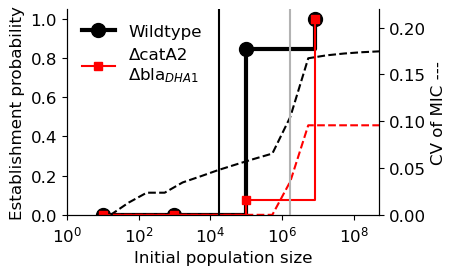

In [301]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()


ax1.set_prop_cycle(color = ['k', 'r'])
ax2.set_prop_cycle(color = ['k', 'r'])

ax1.step(experimental_starting, experimental_growth_probabilities,'-o', label = 'Wildtype', markersize = 10, lw = 3, where = 'post')
ax1.step(experimental_starting, experimental_growth_probabilities_no_gdas, '-s',label = 'ΔcatA2\nΔbla$_{DHA1}$', where = 'post')

ax1.set_ylim([0, 1.05])
ax1.legend(frameon = False)

ax2.set_ylim([0,0.22])
ax2.plot(starting_cells, np.array(het_gda)[:,2], '--', label = 'CV with GDAs')
ax2.plot(starting_cells, np.array(het_no_gda)[:,2], '--', label = 'CV without GDAs')
plt.xscale('log')

ax1.set_xlabel('Initial population size')
ax1.set_ylabel('Establishment probability')
ax2.set_ylabel('CV of MIC ---')

plt.axvline(starting_cells[np.argmax(cell_diff==0)-1], c = 'k', label = 'Model with GDAs')
plt.axvline(starting_cells[np.argmax(cell_diff_no_gda==0)-1], c = '0.7', label = 'Model no GDAs')

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)


plt.xlim([1,5*10**8])
plt.xscale('log')


plt.tight_layout()


fig.savefig('Paper_figures/Establishment_CV_MIC.svg')

fig.savefig('Paper_figures/Establishment_CV_MIC.png', dpi = 300)







## Some additional plots

GDA and mutant fractions

In [ ]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)

base.gluc_start = 2.5 # Resource amount has to be set for the run after next. 2.5 is the concentration that results in cell number corresponding to OD 0.5 in 6 ml tube, which is the condition of the experiment.
base.conduct(1) #  Grow up colony

base.volume = 10
base.sample_volume = 0.1
base.gluc_start = 40
base.conduct(1) # Grow in 6 ml tube to OD 0.5

In [304]:
base.background_fractions[-1]

[np.float64(0.9999996832050684),
 np.float64(2.855125328006038e-07),
 np.float64(3.1282398911744904e-08)]

Text(0, 0.5, 'cfu/ml')

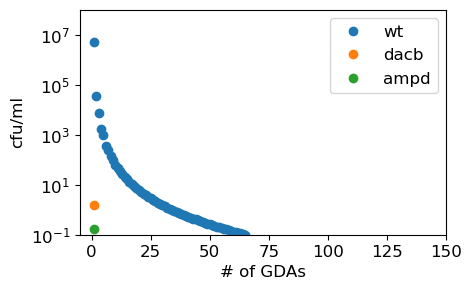

In [305]:
for k, v in base.get_backgrounds().items():
    alln = [g.n[-1] for g in v]
    allg = [g.gdas for g in v]
    plt.plot(allg, alln, 'o',label = k)
    plt.yscale('log')
plt.legend()
plt.xlim([-5,150])
plt.ylim([10**-1,10**8])
plt.xlabel('# of GDAs')
plt.ylabel('cfu/ml')

Text(0.5, 0.9, 'Population fraction\nw/o GDAs: 0.984')

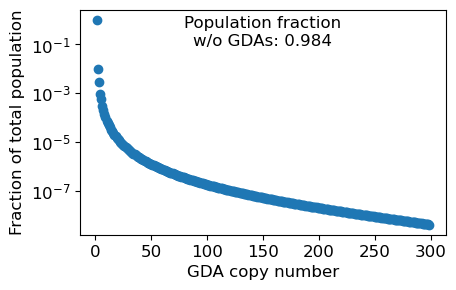

In [314]:
plt.plot(base.from_genos('gdas')[:299], base.fractions[-2][:299],'o')
plt.yscale('log')
plt.xlabel('GDA copy number')
plt.ylabel('Fraction of total population')
plt.text(0.5, 0.9, f'Population fraction\nw/o GDAs: {round((base.fractions[-2][0]),3)}', ha='center', va='center', transform=plt.gca().transAxes)

Theoretical mutation-selection balance (equilibrium frequency of deleterious mutation in population): mutation_rate/fitness_cost

In [309]:
# Calculate for dacb without GDAs:
ms_dacb = base.genotypes[300].mutant_dict['dacb'][0]/base.genotypes[300].mutant_dict['dacb'][1]

Comparison to simulation:

Text(0, 0.5, 'Fraction of cells')

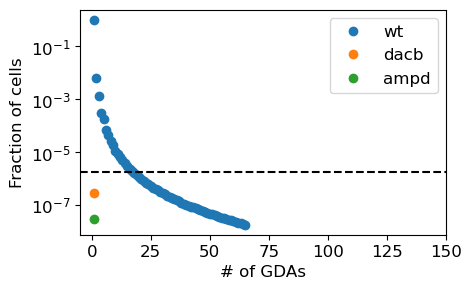

In [308]:
for k, v in base.get_backgrounds().items():
    alln = [g.n[-1] for g in v]
    allg = [g.gdas for g in v]
    plt.plot(allg, np.array(alln)/np.sum(base.from_genos('n')[-1]), 'o',label = k)
    plt.yscale('log')
plt.legend()
plt.xlim([-5,150])
plt.axhline(ms_dacb, ls = '--', c = 'k', label = 'Mutation-selection balance of $dacB$')
#plt.ylim([10**-1,10**8])
plt.xlabel('# of GDAs')
plt.ylabel('Fraction of cells')

Running more cycles brings frequency close to theoretical value:

In [310]:
base.conduct(20)

Text(0, 0.5, 'Fraction of cells')

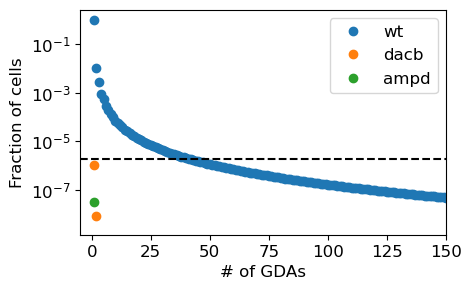

In [311]:
for k, v in base.get_backgrounds().items():
    alln = [g.n[-1] for g in v]
    allg = [g.gdas for g in v]
    plt.plot(allg, np.array(alln)/np.sum(base.from_genos('n')[-1]), 'o',label = k)
    plt.yscale('log')
plt.legend()
plt.xlim([-5,150])
plt.axhline(ms_dacb, ls = '--', c = 'k', label = 'Mutation-selection balance of $dacB$')
#plt.ylim([10**-1,10**8])
plt.xlabel('# of GDAs')
plt.ylabel('Fraction of cells')

And closer....

In [312]:
base.conduct(20)

Text(0, 0.5, 'Fraction of cells')

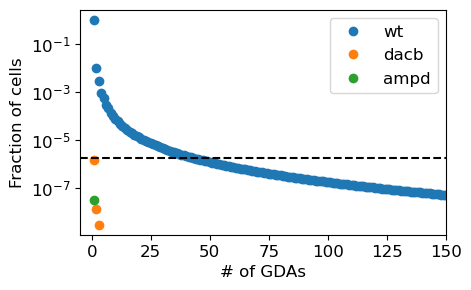

In [313]:
for k, v in base.get_backgrounds().items():
    alln = [g.n[-1] for g in v]
    allg = [g.gdas for g in v]
    plt.plot(allg, np.array(alln)/np.sum(base.from_genos('n')[-1]), 'o',label = k)
    plt.yscale('log')
plt.legend()
plt.xlim([-5,150])
plt.axhline(ms_dacb, ls = '--', c = 'k', label = 'Mutation-selection balance of $dacB$')
#plt.ylim([10**-1,10**8])
plt.xlabel('# of GDAs')
plt.ylabel('Fraction of cells')

## Supplement
Figure S11

In [ ]:
base = Experiment([Genotype(mumax = 1.7, gda_cost = 10**-3, gda_benefit = 3, k_dup = 6*10**-4, k_rec = 0.2, min_dr = -0.1, hill = 8, mutant_dict={'dacb':(2*10**-8 * (1434/(564+1434)),0.008, 751), 'ampd':(2*10**-8 * (564/(564+1434)),0.175, 3073)})], gluc_start=1, volume = 6, sample_volume=1)


base.gluc_start = 2.5 # For some reason, this has to be set befor the conduct....
base.conduct(1) # Run with 1 glucose
base.gluc_start = 1
base.sample_volume = 0.12
base.conduct(1)

antibs =[0,1,2,4,16,32,128]
gdas = []
for a in antibs:
    exp = deepcopy(base)
    exp.set_antibiotic(a)
    #exp.sample_volume = 6
    exp.conduct(1)
    #print(a, exp.background_fractions[-1])
    gdas.append(exp.average_gdas[-1])

0 [np.float64(0.999999675877562), np.float64(3.241224377540625e-07), np.float64(0.0)]
1 [np.float64(0.9999996757285803), np.float64(3.2427141945923833e-07), np.float64(0.0)]
2 [np.float64(0.9999996351761294), np.float64(3.64823870416218e-07), np.float64(0.0)]
4 [np.float64(0.9999495515090244), np.float64(4.910546050266624e-05), np.float64(1.343030472899325e-06)]
16 [np.float64(0.9928777239876254), np.float64(0.007038894820757547), np.float64(8.338119161707885e-05)]
32 [np.float64(0.928901391427748), np.float64(0.07053282365207364), np.float64(0.0005657849201785037)]
128 [np.float64(0.0728508900940738), np.float64(0.9223597289098985), np.float64(0.004789380996027746)]


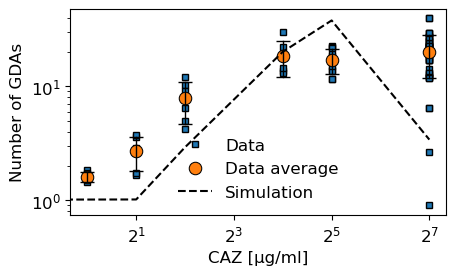

In [ ]:
gda_df = pd.read_excel('./gda_df.xlsx')

f = plt.figure(figsize = figsize)

plt.plot(gda_df['ab'], gda_df['gda'],'s', mec = 'k', label = 'Data', ms = 5)
sns.lineplot(x = 'ab', y = 'gda', data = gda_df, marker = 'o', markersize = 9, err_style='bars', linestyle = '', errorbar='sd', mec = 'k', label = 'Data average', err_kws={'capsize':5, 'ecolor':'k', 'elinewidth':1})
plt.plot(antibs, gdas, '--', c='k', label = 'Simulation')

plt.xscale('log', base = 2)
plt.xlabel('CAZ [µg/ml]')
plt.ylabel('Number of GDAs')
plt.legend(frameon = False)
plt.yscale('log')
#plt.xlim([0,20])

f.tight_layout()

# f.savefig('Paper_figures/Average_gda_vs_AB_fit_log.svg')
# f.savefig('Paper_figures/Average_gda_vs_AB_fit_log.png', dpi = 300)

Simulate PAP-assay:

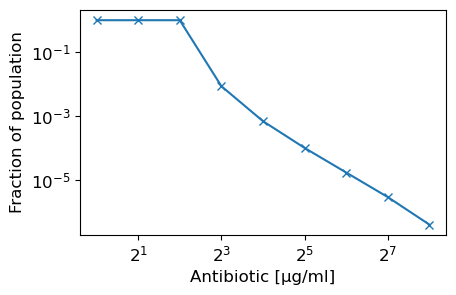

In [11]:
base.pap_assay(end_ab=256);

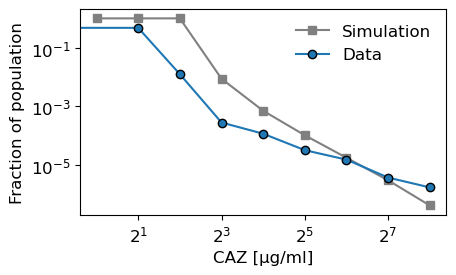

In [ ]:
pap = pd.read_excel('./pap_data.xlsx')


pap_sim = base.pap_assay(end_ab=256, plot = False)

f = plt.figure(figsize=figsize)

plt.plot(*pap_sim.T, '-s', c = 'gray', label = 'Simulation')


plt.yscale('log')
plt.xscale('log', base = 2)
plt.xlabel('CAZ [µg/ml]')
plt.ylabel('Fraction of population')


plt.plot(pap.ab, pap.freq, '-o', mec = 'k', label = 'Data')
plt.legend(frameon = False)

plt.tight_layout()

# f.savefig('Paper_figures/PAP_assay.svg')
# f.savefig('Paper_figures/PAP_assay.png', dpi = 300)
